### Gradient Descent Intuition 

its an optimisation algorithm 

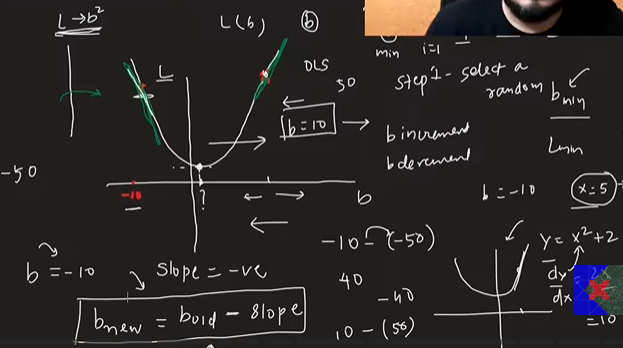

### Mathematical Formulation 

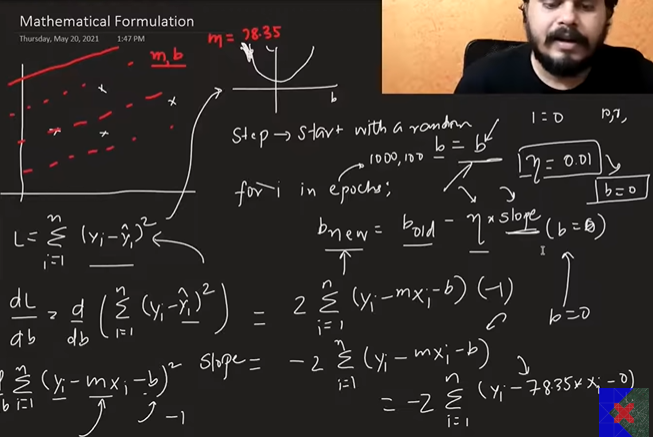

### Step-by-Step

In [3]:
from sklearn.datasets import make_regression
import numpy as np

In [6]:
X,y=make_regression(n_samples=4,n_features=1,n_informative=1,n_targets=1,noise=80,random_state=13)

In [7]:
import matplotlib.pyplot as plt

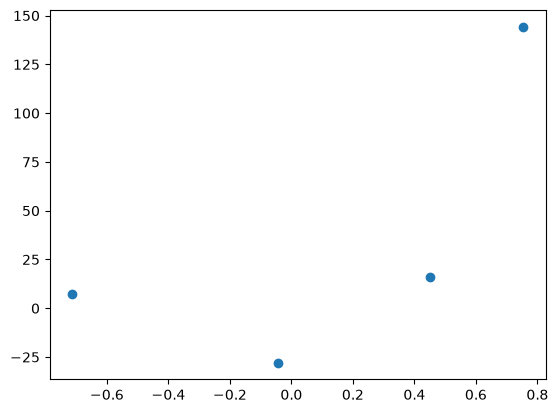

In [8]:
plt.scatter(X,y)

In [9]:
#lts apply OLS 
from sklearn.linear_model import LinearRegression

In [11]:
reg=LinearRegression()
reg.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [12]:
reg.coef_

array([78.35063668])

In [14]:
reg.intercept_    # this is the real answer kise bhi krke hame yah tak puchna h

np.float64(26.15963284313262)

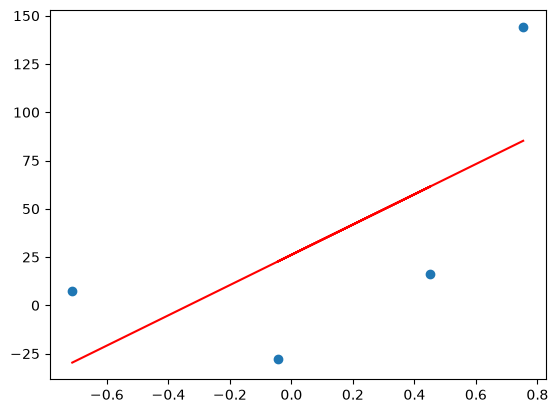

In [16]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

In [17]:
# Lets apply GD assuming m=78.35 and starting value of b as 0
y_pred=((78.35 * X)+0).reshape(4)

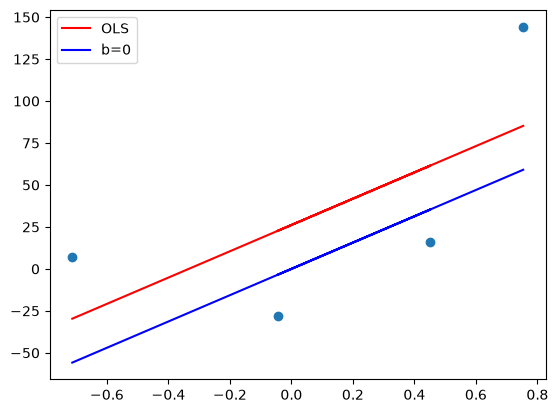

In [22]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='blue',label='b=0')
plt.legend()

In [23]:
# gradually blue line will shift to red
m = 78.35
b = 100

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope
     

np.float64(590.7223659179078)

In [25]:
# Lets take learning rate = 0.1
lr = 0.1

step_size = loss_slope*lr  #from maths formula derived earlier
step_size

np.float64(59.072236591790784)

In [26]:
b = b - step_size
b

np.float64(40.927763408209216)

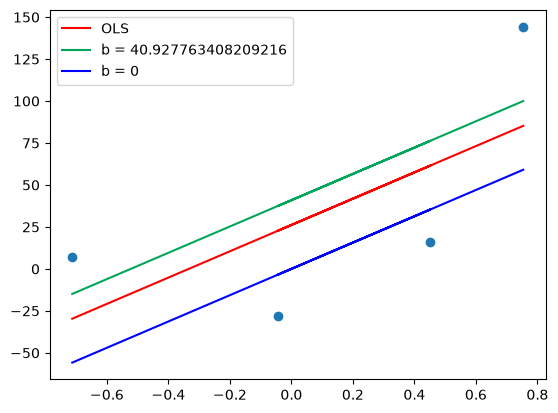

In [28]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred,color='blue',label='b = 0')
plt.legend()
plt.show()

#### Iteration 2 

In [29]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(118.14447318358157)

In [30]:
step_size = loss_slope*lr
step_size

np.float64(11.814447318358157)

In [31]:
b = b - step_size
b

np.float64(29.11331608985106)

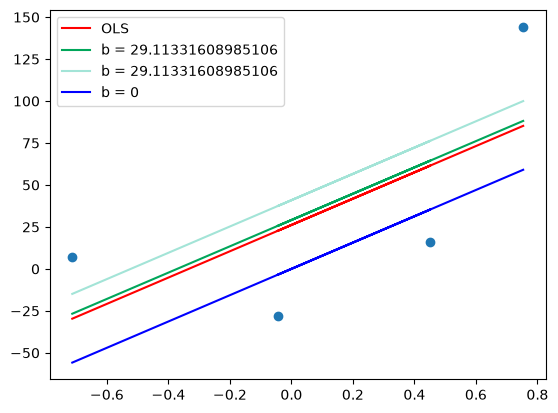

In [33]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred2,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='blue',label='b = 0')
plt.legend()
plt.show()

#### Iteration 3

In [34]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(23.62889463671634)

In [35]:
step_size = loss_slope*lr
step_size

np.float64(2.362889463671634)

In [36]:
b = b - step_size
b

np.float64(26.750426626179426)

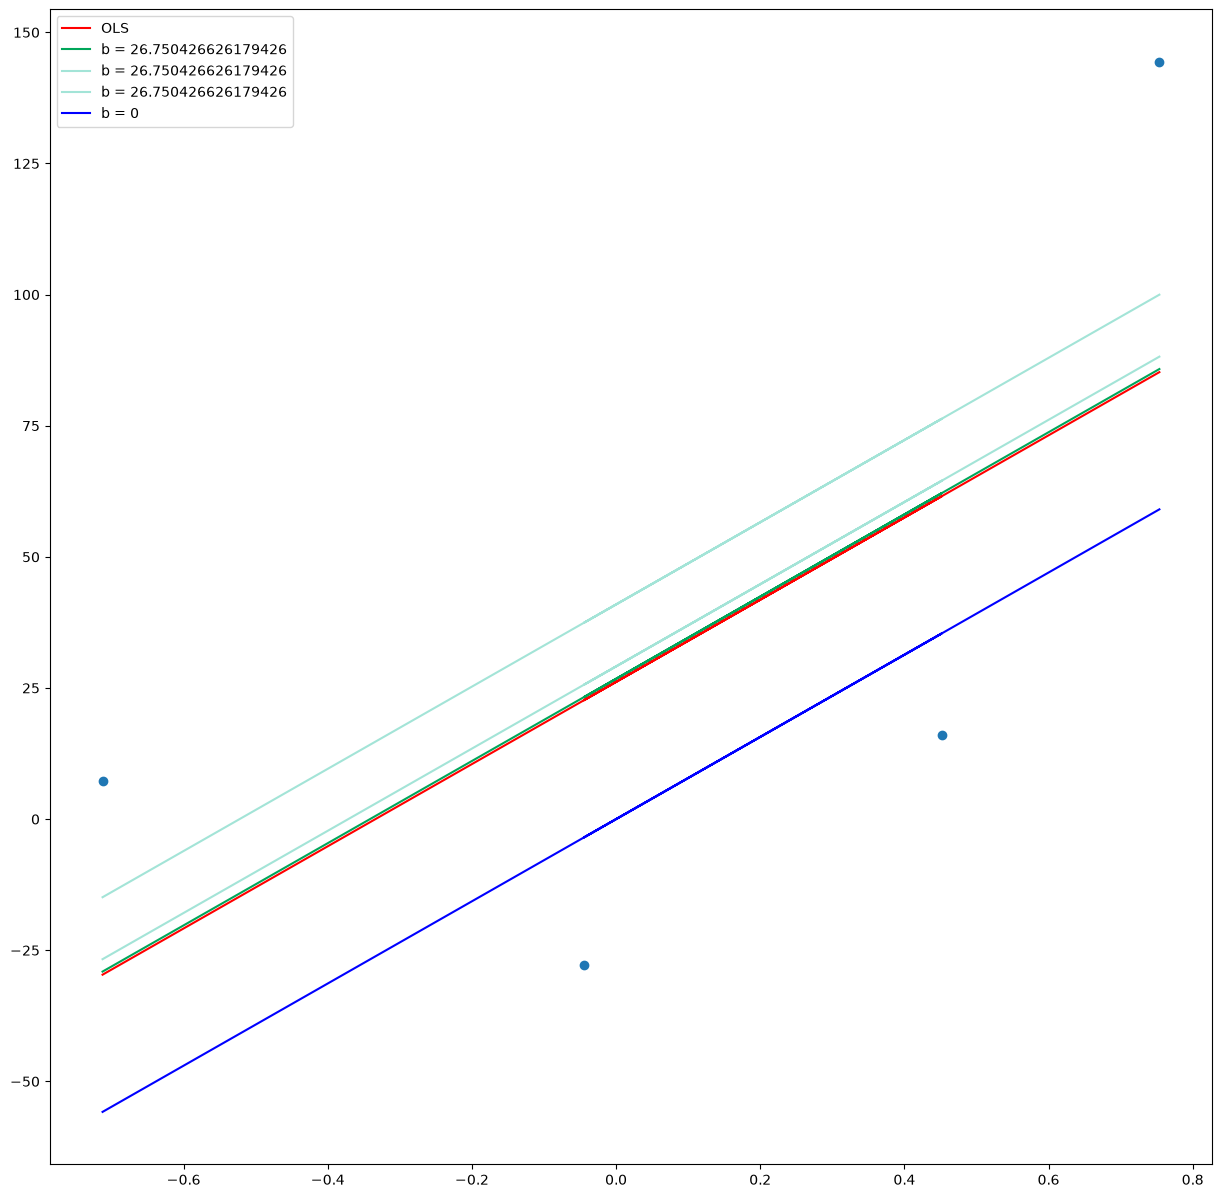

In [37]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred3,color='#00a65a',label='b = {}'.format(b))
plt.plot(X,y_pred2,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred1,color='#A3E4D7',label='b = {}'.format(b))
plt.plot(X,y_pred,color='blue',label='b = 0')
plt.legend()
plt.show()

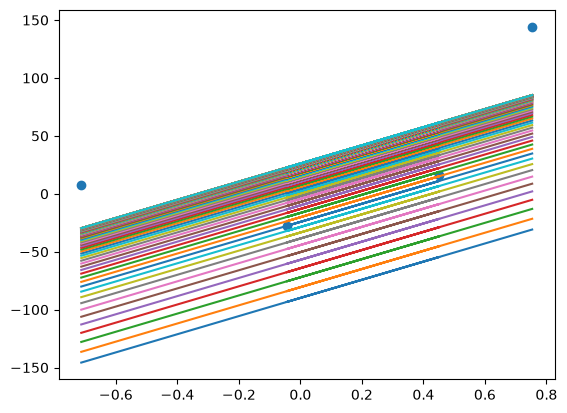

In [39]:
b = -100
m = 78.35
lr = 0.01  # learning rate jitna chota good jyda bada toh prblm 

epochs = 100  # no. of steps || jitna badhenge utna closer line we will get 

for i in range(epochs):
  loss_slope = -2 * np.sum(y - m*X.ravel() - b)
  b = b - (lr * loss_slope)

  y_pred = m * X + b

  plt.plot(X,y_pred)

plt.scatter(X,y)